# E32 · Building a custom likelihood: media spend that chases demand

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Conjura's open multi-brand e-commerce MMM dataset (Anderson 2024, CC BY 4.0): 884 days (Jan 2022 - Jun 2024) of one UK skincare brand - new customers, discounts, and daily Google + Meta spend |
| **You will learn** | How to go from "the standard likelihood is wrong" to a likelihood you derive yourself: write the data-generating story first · spot *which* assumption fails (spend is not set independently of demand) · pick an identification strategy and say what it costs · derive a **Gaussian-copula likelihood with a discrete (negative binomial) margin** · implement it stably (`ndtri_exp`, log-space differences, tail switching) as a `pm.CustomDist` with its own `random` · **unit-test a likelihood** (reduces to NB at rho = 0, sums to one, matches Monte Carlo, correct gradients, finite in the tails) · fake-data checks that show a first fix working, then failing, then a generalised fix - which in turn fails on the real data, and how to diagnose that from the chains · a placebo test · turning the posterior into a marginal-CAC budget decision |

Every marketing mix model (MMM) regresses sales on spend, and every MMM quietly assumes that
**spend was set independently of the demand shock of the day**. That assumption is
false almost everywhere. Budgets go up for Black Friday and payday, bid algorithms (Google
Performance Max, Meta Advantage+) spend more when conversion rates are high, and marketers
pull back in quiet weeks. When spend chases demand, "we spent more and sold more" is partly
"we spent more *because* we were going to sell more", and a regression reads the second part
as media effect.

There is no `pm.EndogenousNegativeBinomial`. This notebook is about what to do when the
likelihood you need does not exist. It is organised as a worked piece of reasoning, and the
order of the steps is the lesson:

1. fit the standard model and see what it says (section 2);
2. write down how the data were actually generated, and find the broken assumption (3);
3. choose what extra assumption will identify the effect, and what it costs (3);
4. derive the likelihood on paper (4), implement it, and **test it like any other code** (5);
5. check on simulated data that it recovers a known answer - and find where it does not (6);
6. fit the real data, attack the result with a placebo test (7), and make the decision (8).

In [1]:
import logging

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The brief and the data

> *"Our dashboard says a new customer costs us about £14 in paid media, and every time we
> push spend up, new customers go up with it. Finance wants to know: if we raise the paid
> budget by 20% for the next year, what will each **extra** customer cost?"*
> - Head of Growth, a UK skincare brand

The question is about the **marginal** customer, not the average one. The brand is one of
the anonymised series in Conjura's open MMM dataset: daily first-time purchases (new
customers), all purchases with their list price and discounts, and spend by channel.

In [2]:
data.describe("conjura_mmm")
raw = data.load("conjura_mmm")
SERIES = "07a680d6fd5e932a9507529ee1240d88"  # UK territory of a Face & Body Care brand
df = raw[raw["MMM_TIMESERIES_ID"] == SERIES].sort_values("DATE_DAY").reset_index(drop=True)
df["date"] = pd.to_datetime(df["DATE_DAY"])
df = df[df["date"] >= "2022-01-01"].reset_index(drop=True)
spend_cols = [c for c in df.columns if c.endswith("_SPEND")]
used = [c for c in spend_cols if df[c].notna().any()]
print("channels used:", used)
df["spend"] = df[spend_cols].fillna(0).sum(axis=1)
df["discount"] = df["ALL_PURCHASES_GROSS_DISCOUNT"] / df["ALL_PURCHASES_ORIGINAL_PRICE"]
print(df[["FIRST_PURCHASES", "spend", "discount"]].describe().round(2).T)
print("days:", len(df), df["date"].min().date(), "->", df["date"].max().date(),
      "| gaps:", int((df["date"].diff().dt.days > 1).sum()))
print(f"dashboard CAC = total spend / total new customers = "
      f"£{df['spend'].sum() / df['FIRST_PURCHASES'].sum():.2f}")

conjura_mmm: 132,759 brand x territory x day rows (143 anonymised series from 93 e-commerce brands, 2019-2024): first-time and all purchases (orders, units, original price, discount), and spend / clicks / impressions for Google (search, shopping, PMax, display, video), Meta (Facebook, Instagram, other) and TikTok, plus organic/direct/email/referral clicks. Missing spend means the brand did not use that channel.
  source: Anderson, A. (2024), Multi-Region Marketing Mix Modelling (MMM) Dataset for Several eCommerce Brands, Conjura, figshare, doi:10.6084/m9.figshare.25314841 (CC BY 4.0).
  url:    https://ndownloader.figshare.com/files/46779652


channels used: ['GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND', 'META_OTHER_SPEND']
                 count     mean     std     min      25%      50%      75%  \
FIRST_PURCHASES  884.0   135.81   70.94   50.00   100.00   122.00   152.25   
spend            884.0  1950.52  769.59  759.37  1393.28  1840.00  2353.62   
discount         884.0     0.10    0.03    0.03     0.07     0.09     0.11   

                     max  
FIRST_PURCHASES   984.00  
spend            6343.85  
discount            0.26  
days: 884 2022-01-01 -> 2024-06-02 | gaps: 0
dashboard CAC = total spend / total new customers = £14.36


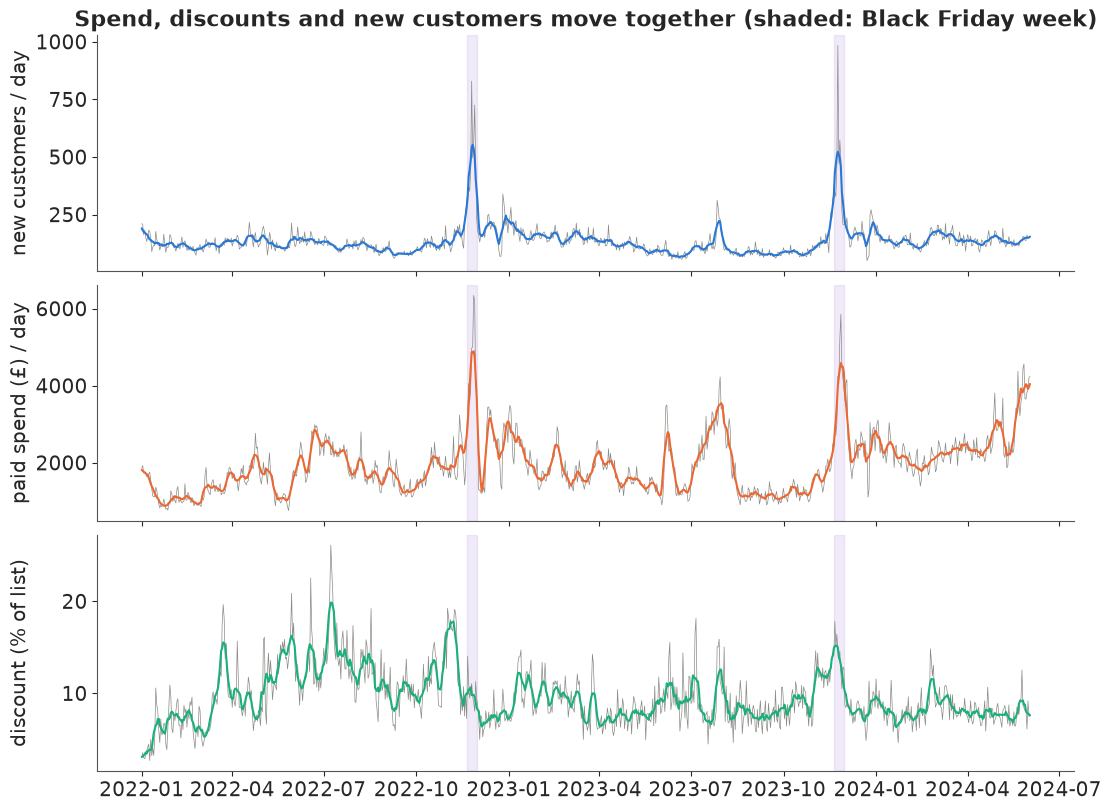

In [3]:
y = df["FIRST_PURCHASES"].to_numpy().astype(int)
spend = df["spend"].to_numpy()
disc = df["discount"].to_numpy()
disc_c = disc - disc.mean()
dates = df["date"]
n = len(y)
t_years = np.arange(n) / 365.25
dow = dates.dt.dayofweek.to_numpy()
K_FOURIER = 4
fourier = np.column_stack([f(2 * np.pi * k * t_years) for k in range(1, K_FOURIER + 1)
                           for f in (np.sin, np.cos)])
X_SCALE = spend.mean()
x = spend / X_SCALE  # spend in units of the average day

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
roll = lambda v: pd.Series(v).rolling(7, center=True, min_periods=1).mean()  # noqa: E731
axes[0].plot(dates, y, color=GREY, lw=0.5)
axes[0].plot(dates, roll(y), color=BLUE, lw=1.5)
axes[0].set_ylabel("new customers / day")
axes[1].plot(dates, spend, color=GREY, lw=0.5)
axes[1].plot(dates, roll(spend), color=ORANGE, lw=1.5)
axes[1].set_ylabel("paid spend (£) / day")
axes[2].plot(dates, 100 * disc, color=GREY, lw=0.5)
axes[2].plot(dates, roll(100 * disc), color=AQUA, lw=1.5)
axes[2].set_ylabel("discount (% of list)")
for ax in axes:
    for yr in (2022, 2023):
        ax.axvspan(pd.Timestamp(f"{yr}-11-20"), pd.Timestamp(f"{yr}-11-30"), color=PURPLE, alpha=0.12)
axes[0].set_title("Spend, discounts and new customers move together (shaded: Black Friday week)")
fig.align_ylabels();

Three things to notice before modelling. Spend and new customers move together, strongly, on
every time scale: the correlation of daily values is printed below. The biggest spikes in
both are the **same days**: Black Friday and the other sale events. Discounts, by contrast, peak
in the summer, so they are a useful control but not the explanation of the spikes.
And spend is **not** a smooth planned budget. It jumps day to day, which is what bid
algorithms do when they chase conversion rates.

In [4]:
print(f"corr(spend, new customers), daily:           {np.corrcoef(spend, y)[0, 1]:.2f}")
print(f"corr(discount, new customers), daily:        {np.corrcoef(disc, y)[0, 1]:.2f}")
print(f"corr(discount, spend), daily:                {np.corrcoef(disc, spend)[0, 1]:.2f}")
wk = pd.DataFrame({"y": y, "s": spend}, index=dates).resample("W").sum()
print(f"corr(spend, new customers), weekly totals:   {np.corrcoef(wk['s'], wk['y'])[0, 1]:.2f}")

corr(spend, new customers), daily:           0.62
corr(discount, new customers), daily:        0.13
corr(discount, spend), daily:                0.09
corr(spend, new customers), weekly totals:   0.65


## 2 · The standard model

A conventional Bayesian MMM for a count outcome. Media effect: geometric **adstock**
(carry-over, weight $\theta^\ell$ for $\ell = 0..20$ days, normalised) followed by a
**saturating** curve $\beta\,a_t/(a_t + k)$, where $a_t$ is adstocked spend in units of an
average day, $\beta$ is the maximum number of customers a day that media can add, and $k$ is
the half-saturation point. Baseline: multiplicative trend, day of week, yearly Fourier
terms and the discount rate. Media adds customers on top of the baseline (an additive
structure makes "customers bought by media" a well-defined quantity). The likelihood is
negative binomial:

$$y_t \sim \text{NB}(\mu_t, \alpha),\qquad \mu_t = \underbrace{\exp(\eta_t)}_{\text{baseline}} + \underbrace{\beta\,\frac{a_t}{a_t + k}}_{\text{media}}.$$

The model-building function takes the likelihood as an argument, because the likelihood is
the one piece that will change.

In [5]:
L_ADSTOCK = 21
LAG_IDX = np.arange(n)[:, None] + (L_ADSTOCK - 1) - np.arange(L_ADSTOCK)[None, :]


def geometric_filter(v, decay, normalise=True):
    """out[t] = sum_l w_l v[t-l], w_l = decay**l (l = 0..20), zero before the start."""
    w = decay ** pt.arange(L_ADSTOCK)
    if normalise:
        w = w / w.sum()
    vpad = pt.concatenate([pt.zeros(L_ADSTOCK - 1), v])
    return (vpad[LAG_IDX] * w[None, :]).sum(axis=1)


def adstock_np(v, theta):
    """NumPy adstock for many draws at once: theta (draws,) -> (draws, n)."""
    w = theta[:, None] ** np.arange(L_ADSTOCK)[None, :]
    w = w / w.sum(axis=1, keepdims=True)
    vpad = np.concatenate([np.zeros(L_ADSTOCK - 1), v])
    return np.einsum("tl,dl->dt", vpad[LAG_IDX], w)


def mmm(y_obs, x_obs, likelihood, name=""):
    """NB-MMM skeleton. `likelihood(mu, alpha)` adds the observed node."""
    coords = {"dow": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
              "fourier": np.arange(2 * K_FOURIER), "day": np.arange(n)}
    with pm.Model(coords=coords, name=name) as model:
        b0 = pm.Normal("b0", np.log(y_obs.mean()), 1.0)
        trend = pm.Normal("trend", 0.0, 0.5)
        g_dow = pm.ZeroSumNormal("g_dow", 0.2, dims="dow")
        g_four = pm.Normal("g_four", 0.0, 0.3, dims="fourier")
        g_disc = pm.Normal("g_disc", 0.0, 2.0)
        baseline = pm.math.exp(b0 + trend * t_years + g_dow[dow] + pt.dot(fourier, g_four)
                               + g_disc * disc_c)
        theta = pm.Beta("theta", 2.0, 2.0)
        k_half = pm.LogNormal("k_half", 0.0, 0.7)
        beta = pm.HalfNormal("beta", 2 * y_obs.mean())
        a = geometric_filter(pt.as_tensor(x_obs), theta)
        mu = baseline + beta * a / (a + k_half)
        alpha = pm.Gamma("alpha", 2.0, 0.1)
        likelihood(mu, alpha)
    return model


def nb_likelihood(y_obs):
    return lambda mu, alpha: pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=y_obs, dims="day")


def fit(model, **kw):
    """4 chains; copula fits (section 6 on) use draws=500 - enough ESS, half the runtime."""
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, **kw)
    print(f"  {model.name or 'model'}: divergences = {int(idata.sample_stats['diverging'].sum())}, "
          f"tuning steps = {idata.posterior.attrs.get('tuning_steps')}")
    return idata


m_naive = mmm(y, x, nb_likelihood(y))
prior = pm.sample_prior_predictive(model=m_naive, draws=500, random_seed=RANDOM_SEED)
prior_y = prior.prior_predictive["y"].values.reshape(-1, n)
print("prior predictive daily new customers, 5/50/95%:",
      np.quantile(prior_y, [0.05, 0.5, 0.95]).round(0), "| observed range:", y.min(), "-", y.max())

prior predictive daily new customers, 5/50/95%: [  47.  255. 1386.] | observed range: 50 - 984


The prior predictive covers the observed range without putting much mass on the absurd
(hundreds of thousands of customers a day). Fit:

In [6]:
idata_naive = fit(m_naive)
PARAMS = ["b0", "trend", "g_disc", "theta", "k_half", "beta", "alpha"]
az.summary(idata_naive, var_names=PARAMS, round_to=3)

  model: divergences = 0, tuning steps = 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,3.688,0.230,3.335,4.049,115.920,219.717,1.026,0.022,0.006
trend,-0.249,0.054,-0.336,-0.165,275.457,591.499,1.010,0.003,0.001
g_disc,6.261,1.156,4.491,8.129,189.509,366.306,1.016,0.084,0.019
theta,0.053,0.032,0.012,0.112,4667.316,2544.913,1.000,0.000,0.001
k_half,2.990,1.544,1.528,6.152,102.646,100.259,1.030,0.168,0.132
beta,369.416,111.280,256.897,589.990,106.595,94.976,1.028,12.067,10.386
alpha,22.866,1.245,20.971,24.845,5118.691,3199.712,1.001,0.017,0.021


No divergences, but look at `b0`, `k_half` and `beta`: bulk ESS near 100 and r_hat 1.03.
The baseline level and the media maximum trade off along a ridge - more media and less
baseline fit the data equally well. Keep that in mind: the *level* of the media effect is
weakly identified, a point that returns in section 8. (More tuning would raise the ESS;
it would not remove the ridge.) Taken at face value, the model says more than half of all
new customers are bought by media, with a response curve that is still steep at current
spend. To answer the brief,
turn draws into the **marginal CAC of a +20% budget**: the extra spend over the whole
period divided by the extra customers the response curve predicts. Adstock is linear, so
raising every day's spend by 20% raises every adstocked value by 20%.

In [7]:
def media_draws(idata, x_obs, prefix="", n_draws=1000):
    post = az.extract(idata, var_names=[f"{prefix}theta", f"{prefix}k_half", f"{prefix}beta"],
                      num_samples=n_draws, random_seed=RANDOM_SEED)
    th, kh, be = (post[f"{prefix}{v}"].values for v in ("theta", "k_half", "beta"))
    a = adstock_np(x_obs, th)
    return a, kh[:, None], be[:, None]


def budget_answer(idata, x_obs, spend_obs, prefix="", lift=0.2):
    a, kh, be = media_draws(idata, x_obs, prefix)
    now = be * a / (a + kh)
    more = be * (1 + lift) * a / ((1 + lift) * a + kh)
    extra_customers = (more - now).sum(axis=1)
    return {"media share": now.sum(axis=1) / y.sum(),
            "average iCAC": spend_obs.sum() / now.sum(axis=1),
            "marginal CAC (+20%)": lift * spend_obs.sum() / extra_customers}


def show(answer, label):
    row = {k: f"{np.median(v):7.2f} [{np.quantile(v, 0.05):.2f}, {np.quantile(v, 0.95):.2f}]"
           for k, v in answer.items()}
    return pd.Series(row, name=label)


ans_naive = budget_answer(idata_naive, x, spend)
show(ans_naive, "standard NB model").to_frame()

,standard NB model
media share,"0.69 [0.58, 0.74]"
average iCAC,"20.77 [19.31, 24.57]"
marginal CAC (+20%),"31.67 [28.34, 35.99]"


Read that as the model's answer to finance (median [90% interval]): the share of new
customers that media is responsible for, the average incremental CAC (spend / customers
bought), and the **marginal** CAC of the next 20% of budget. If spend chases demand, all
three are too optimistic. The rest of the notebook is about finding out whether it does,
and by how much.

## 3 · Thinking it through: how were these data generated?

Write the story *before* touching the likelihood. On day $t$ there is a **demand shock**
$u_t$ - everything that moves new customers and is not in the model: a competitor's
stock-out, a TikTok video, the weather, a newsletter, pay day. Then:

- **orders**: $y_t$ depends on the baseline, on media, and on $u_t$;
- **spend**: the bid algorithm sees conversion rates rise during the day and spends more; the
  marketer sees a good week and raises budgets. So spend $s_t$ *also* depends on $u_t$.

```
         u_t  (demand shock, unobserved)
        /    \
       v      v
    spend ---> new customers
```

The NB likelihood says $y_t \mid s_t \sim \text{NB}(\mu(s_t), \alpha)$ with $u_t$ independent of
$s_t$. Under the story, high-spend days are also high-$u$ days, so the observed
$E[y_t \mid s_t]$ rises with spend faster than the causal curve $\mu(s)$ does. That is
omitted-variable bias with a variable we can never measure.

**What would identify the causal curve?** The usual options, and why each is or is not
available here:

| strategy | needs | here? |
|---|---|---|
| randomised geo / holdout experiment | an experiment | no (and the best answer if you can run one) |
| instrumental variable | something that moves spend but not demand (e.g. a platform outage, an auction-price shock) | nothing credible in the data |
| control for the confounder | measure $u_t$ | $u_t$ is unobserved by definition |
| **model the dependence** between spend and $u_t$ | a distributional assumption | yes: the copula approach |

The last option is the **Gaussian copula correction** of Park & Gupta (2012, *Marketing
Science*), widely used in marketing science since. The idea: we observe the whole
distribution of spend. If we assume that the *ranks* of spend and the *ranks* of the demand
shock are jointly Gaussian with correlation $\rho$, then conditioning on today's spend tells
us how large today's demand shock probably was, and the likelihood can subtract that out.

The price is an **assumption we cannot test from these data alone**: the dependence is
Gaussian on the normal-score scale, and spend is *non-normal* (the method is identified
through the difference between how spend enters the causal curve and how its normal score
enters the correction - with Gaussian spend and a linear model, the two are
indistinguishable). Write that down now, because it goes into the answer to finance.

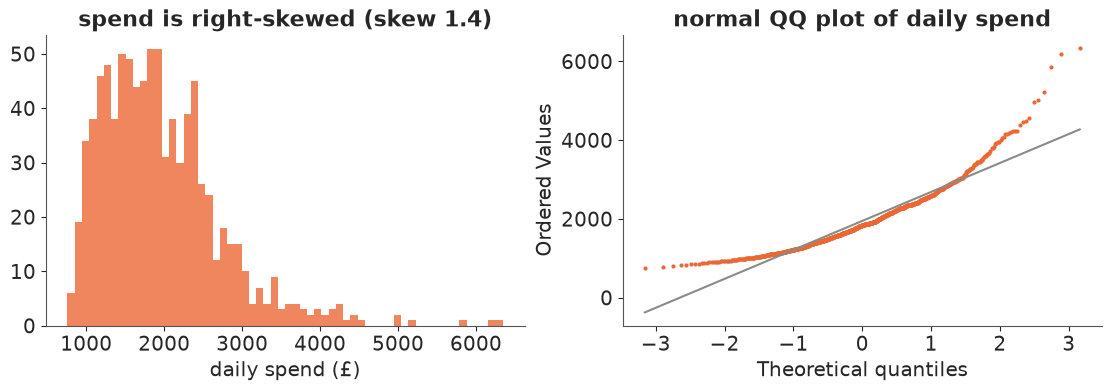

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(spend, bins=60, color=ORANGE, alpha=0.8)
axes[0].set_xlabel("daily spend (£)")
axes[0].set_title(f"spend is right-skewed (skew {stats.skew(spend):.1f})")
stats.probplot(spend, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=ORANGE, markersize=2)
axes[1].get_lines()[1].set(color=GREY)
axes[1].set_title("normal QQ plot of daily spend");

## 4 · Deriving the likelihood

Keep the piece that the standard model gets right, and replace the piece it gets wrong.

**Step 1 - the causal margin.** If spend were set by an experimenter, $y_t$ would follow the
structural model: $y_t \sim \text{NB}(\mu_t, \alpha)$ with CDF $F_t(y)$. This is what we
want to learn: it is the *interventional* distribution, the one a budget change produces.

**Step 2 - put the shock on a common scale.** Any continuous random variable becomes
standard normal through its CDF followed by $\Phi^{-1}$. Let $u_t \sim N(0, 1)$ be the demand
shock on that scale, and generate the count by the inverse-CDF method:
$y_t = F_t^{-1}(\Phi(u_t))$. With $u_t$ standard normal, $y_t$ has exactly the NB margin of step 1.

**Step 3 - the same for spend.** $z_t = \Phi^{-1}(\hat G(s_t))$, where $\hat G$ is the empirical
CDF of spend (using rank / (n + 1)). This is a data transformation, computed once; the
shape of spend's distribution never needs a model.

**Step 4 - the dependence.** Assume $(u_t, z_t)$ is bivariate normal with correlation $\rho$.
Then $u_t \mid z_t \sim N(\rho z_t,\ 1 - \rho^2)$.

**Step 5 - a discrete outcome means an interval, not a density.** Because $y_t$ is a count,
$y_t = y$ happens for a whole *interval* of $u_t$ values:
$F_t(y - 1) < \Phi(u_t) \le F_t(y)$, i.e. $a_{y-1} < u_t \le a_y$ with $a_y = \Phi^{-1}(F_t(y))$.
So

$$P(y_t = y \mid z_t) = \Phi\!\left(\frac{a_y - \rho z_t}{\sqrt{1 - \rho^2}}\right) - \Phi\!\left(\frac{a_{y-1} - \rho z_t}{\sqrt{1 - \rho^2}}\right).$$

That is the whole likelihood. Sanity checks you can do in your head: at $\rho = 0$ it is
$\Phi(a_y) - \Phi(a_{y-1}) = F_t(y) - F_t(y - 1)$, the NB pmf; summed over $y$ it telescopes to
$\Phi(\infty) - \Phi(-\infty) = 1$; with $\rho > 0$ and a high-spend day ($z_t > 0$) it shifts
probability toward large counts - the model now *expects* busy days when spend is high,
without crediting media for it.

For continuous outcomes the copula density has a closed form; the discrete case above is
the reason this likelihood has to be written by hand.

**Numerics.** Naively this is a disaster waiting to happen: in the upper tail $F_t(y)$ is
$1 - 10^{-12}$, $\Phi(\cdot)$ of both bounds is 1.0 in floating point, and the difference is 0.
Three rules keep every subtraction among small, accurately represented numbers:

- **Never compute $1 - F$ as a difference.** The NB CDF is a regularised incomplete beta,
  $F(y) = I_p(\alpha, y + 1)$, and its complement is another one, $1 - F(y) = I_{1-p}(y + 1, \alpha)$.
  Compute both and invert whichever is below 1/2. (A first version used PyMC's NB `logcdf`
  everywhere; test 2 below caught it returning NaN on Black-Friday-sized counts.)
- **Invert in log space**: `pt.ndtri_exp` takes a *log* probability.
- **Subtract in log space**: $\log(e^{A} - e^{B}) = A + \log(1 - e^{B - A})$ (`pt.log1mexp`), and
  when both bounds are above zero use the mirror image $\Phi(-b_{lo}) - \Phi(-b_{hi})$.

The incomplete-beta gradients dominate the cost, so the lower bound reuses the upper one:
$F(y - 1) = F(y) - p(y)$ and $1 - F(y - 1) = 1 - F(y) + p(y)$, where the pmf $p(y)$ is cheap.

In [9]:
def nb_normal_scores(value, mu, alpha):
    """(a_y, a_{y-1}) with a_y = Phi^{-1}(F(y)) for NB(mu, alpha), accurate in BOTH tails.

    F(y) = I_p(alpha, y + 1) and 1 - F(y) = I_{1-p}(y + 1, alpha) with p = alpha / (alpha + mu)
    (regularised incomplete beta). Invert whichever of the two is below 1/2, so the log
    probability handed to ndtri_exp is never a rounded-off log(1 - tiny). The lower bound
    reuses them: F(y-1) = F(y) - pmf(y) and 1 - F(y-1) = (1 - F(y)) + pmf(y), so each row
    needs two incomplete-beta evaluations, not four (they dominate the gradient cost).
    For y = 0, F(-1) = 0 and a_{-1} = -inf; -40 stands in for it and keeps gradients finite.
    """
    log_cdf = pt.log(pt.betainc(alpha, value + 1, alpha / (alpha + mu)))
    log_sf = pt.log(pt.betainc(value + 1, alpha, mu / (alpha + mu)))
    log_pmf = pm.logp(pm.NegativeBinomial.dist(mu=mu, alpha=alpha), value)
    log_cdf_lo = log_cdf + pt.log1mexp(pt.minimum(log_pmf - log_cdf, -1e-12))
    log_sf_lo = pt.logaddexp(log_sf, log_pmf)
    a_hi = pt.switch(log_cdf < np.log(0.5), pt.ndtri_exp(log_cdf), -pt.ndtri_exp(log_sf))
    a_lo = pt.switch(log_cdf_lo < np.log(0.5), pt.ndtri_exp(log_cdf_lo), -pt.ndtri_exp(log_sf_lo))
    return a_hi, pt.switch(pt.eq(value, 0), -40.0, a_lo)


def copula_nb_logp(value, mu, alpha, rho, z):
    """log P(y = value | z) for a NB(mu, alpha) margin in a Gaussian copula with corr rho."""
    a_hi, a_lo = nb_normal_scores(value, mu, alpha)
    s = pt.sqrt(1.0 - rho**2)
    b_hi = (a_hi - rho * z) / s
    b_lo = (a_lo - rho * z) / s
    std = pm.Normal.dist(0.0, 1.0)
    upper = b_lo > 0  # both bounds in the upper tail: use the mirror image
    big = pt.switch(upper, pm.logcdf(std, -b_lo), pm.logcdf(std, b_hi))
    small = pt.switch(upper, pm.logcdf(std, -b_hi), pm.logcdf(std, b_lo))
    return big + pt.log1mexp(small - big)


def copula_nb_random(mu, alpha, rho, z, rng=None, size=None):
    """Simulate the story: u | z ~ N(rho z, 1 - rho^2), then y = F^{-1}(Phi(u))."""
    u = rng.normal(rho * z, np.sqrt(1 - rho**2), size=size)
    return stats.nbinom.ppf(stats.norm.cdf(u), alpha, alpha / (alpha + mu))

`random` follows the generative story directly, which is itself a check: if the logp and the
simulator disagree, one of them is wrong.

## 5 · Test the likelihood like code

A hand-written likelihood is code, and code has bugs. Before it goes near a sampler, run
five tests that each target a specific way to be wrong. Compile the logp and its gradient
once as a plain function:

In [10]:
v_, mu_, al_, rho_, z_ = pt.dvector("y"), pt.dscalar("mu"), pt.dscalar("alpha"), pt.dscalar("rho"), pt.dscalar("z")
lp_expr = copula_nb_logp(v_, mu_, al_, rho_, z_)
logp_fn = pytensor.function([v_, mu_, al_, rho_, z_], lp_expr)
grad_fn = pytensor.function([v_, mu_, al_, rho_, z_],
                            pt.grad(lp_expr.sum(), [mu_, al_, rho_]))
nb_fn = pytensor.function([v_, mu_, al_], pm.logp(pm.NegativeBinomial.dist(mu=mu_, alpha=al_), v_))

grid = np.arange(0, 1500, dtype=float)
cases = [(135.0, 15.0, 0.0, 0.0), (135.0, 15.0, 0.6, 2.0), (135.0, 15.0, -0.8, -3.0),
         (5.0, 0.8, 0.9, 3.0), (400.0, 60.0, 0.5, -1.5)]

print("test 1: rho = 0 reproduces the NB log-pmf")
print("   max |diff| =", np.abs(logp_fn(grid[:600], 135.0, 15.0, 0.0, 1.7) - nb_fn(grid[:600], 135.0, 15.0)).max())
print("test 2: probabilities sum to one")
for c in cases:
    print(f"   mu={c[0]:>5}, alpha={c[1]:>4}, rho={c[2]:>4}, z={c[3]:>4}:  sum = "
          f"{np.exp(logp_fn(grid, *c)).sum():.10f}")

test 1: rho = 0 reproduces the NB log-pmf
   max |diff| = 4.763203085289547e-07
test 2: probabilities sum to one
   mu=135.0, alpha=15.0, rho= 0.0, z= 0.0:  sum = 1.0000000000
   mu=135.0, alpha=15.0, rho= 0.6, z= 2.0:  sum = 1.0000000000
   mu=135.0, alpha=15.0, rho=-0.8, z=-3.0:  sum = 1.0000000000
   mu=  5.0, alpha= 0.8, rho= 0.9, z= 3.0:  sum = 1.0000000000
   mu=400.0, alpha=60.0, rho= 0.5, z=-1.5:  sum = 1.0000000000


test 3: the pmf matches Monte Carlo from the generative story (200k draws)
   (135.0, 15.0, 0.6, 2.0): total variation distance = 0.0120


   (135.0, 15.0, -0.8, -3.0): total variation distance = 0.0100


   (5.0, 0.8, 0.9, 3.0): total variation distance = 0.0062


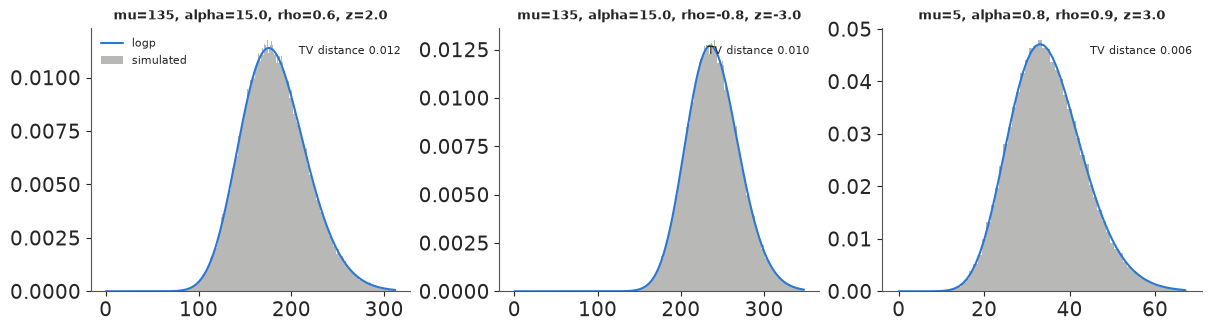

In [11]:
print("test 3: the pmf matches Monte Carlo from the generative story (200k draws)")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, c in zip(axes, [(135.0, 15.0, 0.6, 2.0), (135.0, 15.0, -0.8, -3.0), (5.0, 0.8, 0.9, 3.0)]):
    draws = copula_nb_random(*c, rng=rng, size=200_000)
    hi = int(np.quantile(draws, 0.999))
    emp = np.bincount(draws.astype(int), minlength=hi + 1)[: hi + 1] / draws.size
    pmf = np.exp(logp_fn(np.arange(hi + 1.0), *c))
    ax.bar(np.arange(hi + 1), emp, width=1.0, color=GREY, alpha=0.6, label="simulated")
    ax.plot(np.arange(hi + 1), pmf, color=BLUE, lw=1.5, label="logp")
    ax.set_title(f"mu={c[0]:.0f}, alpha={c[1]}, rho={c[2]}, z={c[3]}", fontsize=9)
    tv = 0.5 * np.abs(emp - pmf).sum()
    ax.text(0.97, 0.9, f"TV distance {tv:.3f}", transform=ax.transAxes, ha="right", fontsize=8)
    print(f"   {c}: total variation distance = {tv:.4f}")
axes[0].legend(fontsize=8);

Total-variation distances of about 0.01 are what 200,000 Monte Carlo draws spread over a few
hundred possible counts give by chance alone (the expected value for these pmfs is about
0.01-0.015): the logp and the simulator describe the same distribution. A wrong logp, such
as one that forgets the $\sqrt{1 - \rho^2}$, gives distances of 0.1 or more.

In [12]:
print("test 4: analytic gradients agree with central finite differences")
yy = np.array([60.0, 135.0, 290.0])
for c in [(135.0, 15.0, 0.6, 2.0), (135.0, 15.0, -0.4, -1.0)]:
    g = grad_fn(yy, *c)
    num = []
    for i in range(3):
        h = 1e-5 * max(1.0, abs(c[i]))
        up, dn = list(c), list(c)
        up[i] += h
        dn[i] -= h
        num.append((logp_fn(yy, *up).sum() - logp_fn(yy, *dn).sum()) / (2 * h))
    print(f"   {c}: analytic {np.round(g, 6)}  numeric {np.round(num, 6)}")

print("test 5: finite far in the tails, where the naive formula is not")
naive_expr = pt.log(pt.exp(pm.logcdf(pm.Normal.dist(0.0, 1.0), (pt.ndtri_exp(pm.logcdf(pm.NegativeBinomial.dist(mu=mu_, alpha=al_), v_)) - rho_ * z_) / pt.sqrt(1 - rho_**2)))
                    - pt.exp(pm.logcdf(pm.Normal.dist(0.0, 1.0), (pt.ndtri_exp(pm.logcdf(pm.NegativeBinomial.dist(mu=mu_, alpha=al_), v_ - 1)) - rho_ * z_) / pt.sqrt(1 - rho_**2))))
naive_fn = pytensor.function([v_, mu_, al_, rho_, z_], naive_expr)
far = np.array([0.0, 20.0, 400.0, 700.0, 1000.0])
print("   y:           ", far)
print("   stable logp: ", logp_fn(far, 135.0, 15.0, 0.6, -2.0).round(2))
print("   naive logp:  ", naive_fn(far, 135.0, 15.0, 0.6, -2.0).round(2))

test 4: analytic gradients agree with central finite differences
   (135.0, 15.0, 0.6, 2.0): analytic [ -0.060785  -0.687335 -33.938497]  numeric [ -0.060785  -0.687335 -33.938497]
   (135.0, 15.0, -0.4, -1.0): analytic [ 0.031927 -0.517978  8.553882]  numeric [ 0.031927 -0.517978  8.553882]
test 5: finite far in the tails, where the naive formula is not
   y:            [   0.   20.  400.  700. 1000.]
   stable logp:  [ -38.57  -14.1   -35.08  -78.75 -125.33]
   naive logp:   [-38.57 -14.1  -35.08   -inf   -inf]


All five pass. Test 5 shows why the log-space form matters. Far in the upper tail, the naive
formula returns $-\infty$ where the true log-probability is finite. A sampler that wanders
there during warm-up gets an infinite gradient or a NaN, and one outlier day (Black Friday)
would be enough to cause it.

## 6 · Does it recover a known answer? A fake-data study

Passing unit tests shows the code computes the formula. It does not show the formula
answers the question. For that, simulate data where the truth is known, with spend that
chases demand, and see whether each model recovers the causal response curve. The design
copies the real series: same days, discount, trend, a true curve with
$\theta = 0.3$, $k = 1$, $\beta = 60$, NB $\alpha = 15$, and spend whose normal score
correlates $0.6$ with the demand shock.

The copula model uses the `mmm` skeleton with a different likelihood:

In [13]:
def normal_scores(v):
    return stats.norm.ppf(stats.rankdata(v) / (len(v) + 1))


def copula_likelihood(y_obs, z_obs, control="same-day"):
    """Park-Gupta ("same-day") or the generalised smoothed control ("smoothed", section 6.2)."""
    def add(mu, alpha):
        rho = pm.Uniform("rho", -0.95, 0.95)
        c = pt.as_tensor(z_obs)
        if control == "smoothed":
            lam = pm.Beta("lam", 2.0, 2.0)
            c = geometric_filter(c, lam, normalise=False)
            c = (c - c.mean()) / c.std()  # the control must be N(0, 1) on the copula scale
        pm.CustomDist("y", mu, alpha, rho, c, logp=copula_nb_logp, random=copula_nb_random,
                      observed=y_obs, dims="day")
    return add


TRUE = {"theta": 0.3, "k_half": 1.0, "beta": 60.0, "alpha": 15.0}


def simulate(phi, rho_true=0.6, seed=5):
    """Demand shock u (AR(1) with coefficient phi); spend reacts to it; orders follow the story."""
    r = np.random.default_rng(seed)
    e = r.normal(size=n)
    u = np.zeros(n)
    for i in range(n):
        u[i] = (phi * u[i - 1] if i else 0.0) + np.sqrt(1 - phi**2) * e[i]
    z_spend = rho_true * u + np.sqrt(1 - rho_true**2) * r.normal(size=n)
    x_sim = np.exp(0.4 * z_spend)  # log-normal: skewed like the real spend
    a = adstock_np(x_sim, np.array([TRUE["theta"]]))[0]
    mu = np.exp(np.log(80) - 0.2 * t_years + 7 * disc_c) + TRUE["beta"] * a / (a + TRUE["k_half"])
    y_sim = stats.nbinom.ppf(stats.norm.cdf(u), TRUE["alpha"], TRUE["alpha"] / (TRUE["alpha"] + mu))
    return y_sim.astype(int), x_sim


def true_curve(mult):
    a_bar = np.exp(0.4**2 / 2)  # mean of the simulated x: average adstocked spend ~ this
    return TRUE["beta"] * mult * a_bar / (mult * a_bar + TRUE["k_half"])

### 6.1 · Independent daily shocks

First the case the textbook method is built for: $u_t$ independent from day to day.

In [14]:
y_iid, x_iid = simulate(phi=0.0)
sim_fits = {}
sim_fits["iid: standard NB"] = (fit(mmm(y_iid, x_iid, nb_likelihood(y_iid), name="iid_nb")), x_iid, "iid_nb::")
sim_fits["iid: copula (same-day)"] = (fit(mmm(y_iid, x_iid, copula_likelihood(y_iid, normal_scores(x_iid)), name="iid_cop"), draws=500), x_iid, "iid_cop::")

  iid_nb: divergences = 0, tuning steps = 400


  iid_cop: divergences = 0, tuning steps = 400


### 6.2 · Persistent shocks

Real demand shocks last: a viral video sells for a week, a competitor's stock-out lasts a
fortnight. Make the shock AR(1) with coefficient 0.7 and refit the same copula model.

Before looking, think about what should happen. Adstock makes today's media effect depend
on the last three weeks of spend. With persistent shocks, *yesterday's* spend was also
high because of a shock that is still running today. The same-day correction conditions
on $z_t$ only, so the part of $u_t$ that is predictable from $z_{t-1}, z_{t-2}, \dots$ is still
being credited to adstocked media.

**The generalisation.** Nothing in the derivation of section 4 required the conditioning
variable to be today's normal score. It needs *some* control $c_t$ with $(u_t, c_t)$
bivariate normal and unit variance. Take a geometrically weighted sum of past and present
spend scores, $c_t \propto \sum_\ell \lambda^\ell z_{t-\ell}$, standardised, and learn
$\lambda$ with everything else. A linear filter of Gaussian scores is Gaussian, so the
likelihood is unchanged: only its fourth argument changes. $\lambda = 0$ gives back
Park-Gupta.

In [15]:
y_ar, x_ar = simulate(phi=0.7)
z_ar = normal_scores(x_ar)
sim_fits["AR(1): standard NB"] = (fit(mmm(y_ar, x_ar, nb_likelihood(y_ar), name="ar_nb")), x_ar, "ar_nb::")
sim_fits["AR(1): copula (same-day)"] = (fit(mmm(y_ar, x_ar, copula_likelihood(y_ar, z_ar), name="ar_cop"), draws=500), x_ar, "ar_cop::")
sim_fits["AR(1): copula (smoothed)"] = (fit(mmm(y_ar, x_ar, copula_likelihood(y_ar, z_ar, "smoothed"), name="ar_sm"),
                                            target_accept=0.95, draws=500), x_ar, "ar_sm::")

  ar_nb: divergences = 0, tuning steps = 400


  ar_cop: divergences = 0, tuning steps = 400


  ar_sm: divergences = 0, tuning steps = 400


In [16]:
rows = []
for label, (idt, _, pre) in sim_fits.items():
    vn = [f"{pre}{v}" for v in ("theta", "k_half", "beta", "alpha")]
    if "copula" in label:
        vn.append(f"{pre}rho")
    if "smoothed" in label:
        vn.append(f"{pre}lam")
    s = az.summary(idt, var_names=vn, round_to=3)
    s.index = [i.split("::")[1] for i in s.index]
    rows.append(s.apply(lambda r: f"{r['mean']:.2f} ± {r['sd']:.2f}", axis=1).rename(label))
recovery = pd.concat(rows, axis=1).T
recovery.loc["TRUE"] = {**{k: f"{v:g}" for k, v in TRUE.items()}, "rho": "0.6 (on u vs z)", "lam": ""}
recovery.fillna("")

,theta,k_half,beta,alpha,rho,lam
iid: standard NB,0.08 ± 0.03,6.00 ± 1.38,412.81 ± 72.18,26.50 ± 1.69,,
iid: copula (same-day),0.59 ± 0.12,2.06 ± 1.27,103.46 ± 34.72,14.74 ± 1.31,0.65 ± 0.03,
AR(1): standard NB,0.36 ± 0.03,9.43 ± 1.48,706.97 ± 95.65,29.89 ± 1.90,,
AR(1): copula (same-day),0.60 ± 0.03,6.58 ± 1.62,411.71 ± 82.62,21.81 ± 1.77,0.53 ± 0.04,
AR(1): copula (smoothed),0.64 ± 0.16,1.79 ± 1.12,80.38 ± 35.19,13.25 ± 1.56,0.75 ± 0.03,0.45 ± 0.04
TRUE,0.3,1,60,15,0.6 (on u vs z),


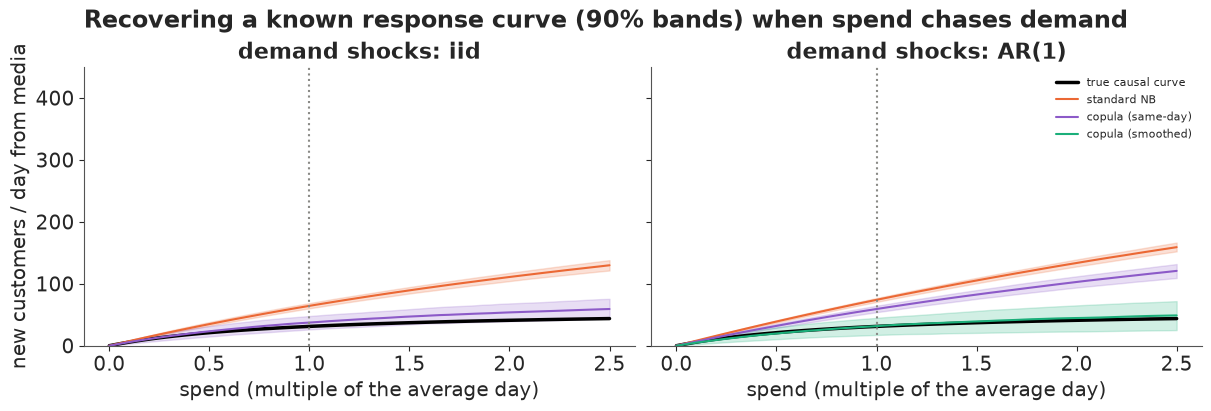

In [17]:
mults = np.linspace(0.0, 2.5, 60)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {"standard NB": ORANGE, "copula (same-day)": PURPLE, "copula (smoothed)": AQUA}
for ax, scen in zip(axes, ["iid", "AR(1)"]):
    ax.plot(mults, true_curve(mults), color="k", lw=2.5, label="true causal curve")
    for label, (idt, xs_, pre) in sim_fits.items():
        if not label.startswith(scen):
            continue
        post = az.extract(idt, var_names=[f"{pre}k_half", f"{pre}beta"], num_samples=500, random_seed=1)
        kh, be = post[f"{pre}k_half"].values[:, None], post[f"{pre}beta"].values[:, None]
        a_bar = xs_.mean()
        curves = be * mults * a_bar / (mults * a_bar + kh)
        lo, med, hi = np.quantile(curves, [0.05, 0.5, 0.95], axis=0)
        c = colors[label.split(": ")[1]]
        ax.fill_between(mults, lo, hi, color=c, alpha=0.2)
        ax.plot(mults, med, color=c, lw=1.5, label=label.split(": ")[1])
    ax.axvline(1.0, color=GREY, ls=":")
    ax.set_xlabel("spend (multiple of the average day)")
    ax.set_title(f"demand shocks: {scen}")
    ax.set_ylim(0, 450)
axes[0].set_ylabel("new customers / day from media")
axes[1].legend(fontsize=8)
fig.suptitle("Recovering a known response curve (90% bands) when spend chases demand");

Read the table and the figure together.

- **Independent shocks.** The standard NB model is badly wrong: its curve at average spend
  is about twice the truth and it keeps rising, so it would promise large gains from more
  budget. The same-day copula recovers the truth within its band and finds $\rho$ close to the
  0.6 that generated the data. The adstock rate is poorly recovered by *both* (a weakly
  identified parameter), but the curve that matters for decisions is right.
- **Persistent shocks.** The same-day copula is now almost as wrong as the standard model -
  the failure predicted above, which the unit tests could never have found. The smoothed
  control recovers the curve, at the price of a wider band (it has to learn $\lambda$ too). It
  needed `target_accept=0.95` to sample without divergences.

So far so good: one likelihood, two controls, and a known answer recovered when the
control matches the story. Real data do not come with the story attached.

## 7 · The real data

Fit both copula versions to the real series, plus the test that matters most for a method
built on an untestable assumption: a **placebo**. Shift the spend scores by half a year
(182 days) before using them as the control. The shifted series keeps its own distribution
and autocorrelation but loses its day-by-day link to demand, so an honest method should find
$\rho \approx 0$ and give back the standard model's answer. A method that finds "endogeneity"
in the placebo is fitting something else - trend or seasonality leaking into the correction.

In [18]:
z = normal_scores(spend)
idata_pg = fit(mmm(y, x, copula_likelihood(y, z), name="pg"), draws=500)
idata_sm = fit(mmm(y, x, copula_likelihood(y, z, "smoothed"), name="sm"), draws=500)
idata_placebo = fit(mmm(y, x, copula_likelihood(y, np.roll(z, 182)), name="placebo"), draws=500)

  pg: divergences = 0, tuning steps = 400


  sm: divergences = 0, tuning steps = 400


  placebo: divergences = 0, tuning steps = 400


In [19]:
def tidy(idt, prefix, extra=()):
    s = az.summary(idt, var_names=[f"{prefix}{v}" for v in ("theta", "k_half", "beta", "alpha", *extra)],
                   round_to=3)
    s.index = [i.split("::")[-1] for i in s.index]
    return s[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]]


with pd.option_context("display.max_rows", 40):
    display(pd.concat({"standard NB": tidy(idata_naive, ""),
                       "copula same-day": tidy(idata_pg, "pg::", ["rho"]),
                       "copula smoothed": tidy(idata_sm, "sm::", ["rho", "lam"]),
                       "placebo (shifted)": tidy(idata_placebo, "placebo::")}))
r_pl = idata_placebo.posterior["placebo::rho"].values.ravel()
print(f"placebo rho: mean {r_pl.mean():.2f}, 89% interval [{np.quantile(r_pl, 0.055):.2f}, "
      f"{np.quantile(r_pl, 0.945):.2f}]")

mean       sd  eti89_lb  eti89_ub  ess_bulk  \
standard NB       theta     0.053    0.032     0.012     0.112  4667.316   
                  k_half    2.990    1.544     1.528     6.152   102.646   
                  beta    369.416  111.280   256.897   589.990   106.595   
                  alpha    22.866    1.245    20.971    24.845  5118.691   
copula same-day   theta     0.221    0.133     0.049     0.467  1303.994   
                  k_half    0.132    0.066     0.055     0.249   267.543   
                  beta    108.600    7.682    98.841   121.812   218.749   
                  alpha    15.670    1.265    13.789    17.879   462.267   
                  rho       0.562    0.045     0.483     0.626   362.015   
copula smoothed   theta     0.104    0.094     0.018     0.298    12.559   
                  k_half    4.099    2.547     0.084     7.367     7.304   
                  beta    518.223  262.224   102.067   858.988     7.303   
                  alpha    19.423    2.526    14.708    22.630     7.360   
                  rho      -0.146    0.411    -0.450     0.593     7.453   
                  lam       0.691    0.368     0.027     0.955     7.255   
placebo (shifted) theta     0.054    0.035     0.011     0.117  2122.779   
                  k_half    3.228    1.772     1.581     6.965    58.420   
                  beta    389.081  127.050   262.776   651.344    60.345   
                  alpha    22.706    1.274    20.773    24.834  2473.438   

                          r_hat  
standard NB       theta   1.000  
                  k_half  1.030  
                  beta    1.028  
                  alpha   1.001  
copula same-day   theta   1.002  
                  k_half  1.018  
                  beta    1.020  
                  alpha   1.010  
                  rho     1.013  
copula smoothed   theta   1.227  
                  k_half  1.549  
                  beta    1.550  
                  alpha   1.525  
                  rho     1.537  
                  lam     1.531  
placebo (shifted) theta   0.999  
                  k_half  1.074  
                  beta    1.075  
                  alpha   1.003

placebo rho: mean -0.12, 89% interval [-0.19, -0.06]


Three results, one per fit.

**The same-day copula** samples cleanly (0-1 divergences in 2000 draws across builds, r_hat
1.00) and finds strong dependence: $\rho \approx 0.56$ - on days when spend is in its top
decile, demand was already unusually high. The response curve changes shape completely:
the half-saturation point drops from about 3 average days of spend to about 0.13. Over the
range of spend this brand actually used, media is nearly **flat**.

**The placebo** returns to the standard model's curve and answer. Its $\rho$ is not exactly
zero: it is small and negative (about -0.12, printed under the table). A half-year shift
lines summer spend up with winter demand, so some seasonal misalignment is to be expected.
What matters is that it is a fifth of the real value, of the opposite sign, and leaves the
curve alone. The dependence the copula found is tied to the *timing* of spend.

**The smoothed control does not converge on the real data** (ESS below 20, r_hat far above
1.01, though no divergences). The chains disagree about *which* explanation holds:

In [20]:
per_chain = pd.DataFrame({v: idata_sm.posterior[f"sm::{v}"].mean("draw").values
                          for v in ("rho", "lam", "k_half", "beta")})
per_chain.index.name = "chain"
per_chain.round(2)

,rho,lam,k_half,beta
chain,,,,
0,-0.38,0.90,5.44,656.75
1,-0.38,0.91,5.41,653.17
2,0.56,0.06,0.13,107.28
3,-0.38,0.90,5.42,655.69


One chain lands on the same-day answer (small $\lambda$, $\rho \approx 0.54$). The other three find a
**negative** $\rho$ on a control smoothed over weeks ($\lambda$ near 0.9). A control that slow is
nearly a seasonal curve, and it competes with the baseline's Fourier terms - exactly the
leakage the placebo is designed to catch. The fake-data study could not show this, because
its baseline was known and simple.

The way out comes from the model itself. The same-day fit puts the adstock rate at
$\theta \approx 0.2$, so 90% of a day's media effect lands within two days. Past spend barely
enters the media term, and the persistent-shock problem that motivated the smoothed control
has little to act on. **For this brand the same-day copula is the model to use**. The
smoothed version stays in the toolbox for brands with long carry-over, where it should be
given a prior that keeps $\lambda$ at the time scale of the adstock.

**Does the corrected model describe the data better?** Both likelihoods give $p(y_t \mid
\text{spend})$ day by day, so LOO compares them directly (for the copula, "given spend" means
given its normal score; the conditioning information is the same).

In [21]:
m_pg = mmm(y, x, copula_likelihood(y, z), name="pg")
loos = {}
for label, idt, mdl in [("standard NB", idata_naive, m_naive), ("copula same-day", idata_pg, m_pg)]:
    pm.compute_log_likelihood(idt, model=mdl, progressbar=False)
    loos[label] = az.loo(idt, pointwise=True)
    loos[label].log_weights = None
    del idt["log_likelihood"]
az.compare(loos, round_to=1)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
copula same-day,0,0.0,0.0,NaN,,1 k̂ > 0.70,31.0,-4216.4,40.7,0.8
standard NB,1,-16.2,7.4,1.0,,1 k̂ > 0.70,31.5,-4232.6,43.1,0.2


The same-day copula is ahead by about 15 elpd points with a standard error of about 7: a
clear but not overwhelming preference, with essentially the same number of effective
parameters (about 31.5 in both). One day per model has Pareto $k > 0.7$ (a Black Friday
spike); with 884 days that does not change the ranking. LOO rewards the copula for
*predicting* busy days from busy spend, which is exactly the dependence it models. It
cannot tell us whether that dependence is demand driving spend (the copula's story) or
spend driving demand on the day (a very short, steep media effect). That distinction is the
untestable assumption, and no amount of model comparison on these data will settle it.

**Posterior predictive check.** With a `random` function, the copula model gets posterior
predictive draws in one line. Two statistics matter here: how strongly new customers
co-move with spend (the slope of $\log(1 + y)$ on the spend score), and how much of that
movement persists from one day to the next.

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run CustomDist_y_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


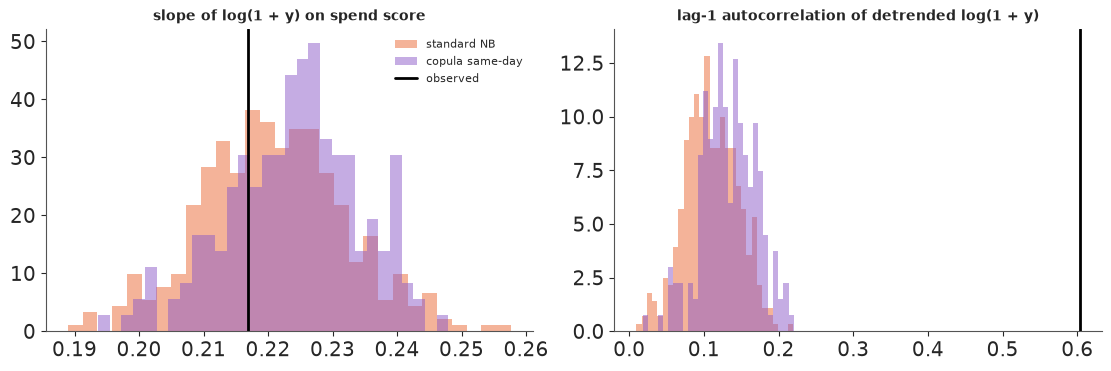

In [22]:
ppc_pg = pm.sample_posterior_predictive(idata_pg.isel(draw=slice(None, None, 10)), model=m_pg,
                                        random_seed=RANDOM_SEED, progressbar=False)
ppc_nb = pm.sample_posterior_predictive(idata_naive.isel(draw=slice(None, None, 10)), model=m_naive,
                                        random_seed=RANDOM_SEED, progressbar=False)
rep_pg = ppc_pg.posterior_predictive["pg::y"].values.reshape(-1, n)
rep_nb = ppc_nb.posterior_predictive["y"].values.reshape(-1, n)


def resid_autocorr(v):
    r = np.log1p(v) - pd.Series(np.log1p(v)).rolling(28, center=True, min_periods=1).mean().to_numpy()
    return np.corrcoef(r[1:], r[:-1])[0, 1]


def slope_on_score(v):
    return np.polyfit(z, np.log1p(v), 1)[0]


fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, fn, title in [(axes[0], slope_on_score, "slope of log(1 + y) on spend score"),
                      (axes[1], resid_autocorr, "lag-1 autocorrelation of detrended log(1 + y)")]:
    for rep, c, lab in [(rep_nb, ORANGE, "standard NB"), (rep_pg, PURPLE, "copula same-day")]:
        ax.hist([fn(r) for r in rep], bins=30, color=c, alpha=0.5, label=lab, density=True)
    ax.axvline(fn(y), color="k", lw=2, label="observed")
    ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=8);

Both models reproduce the co-movement of new customers with spend (left): the standard
model through the media curve, the copula mostly through $\rho$. The check cannot choose
between them, for the reason just given. Both **fail** the persistence check (right):
detrended new customers have a day-to-day autocorrelation of about 0.6, and neither model
gets above 0.25. Demand shocks last several days, and both likelihoods treat days as
independent given their covariates. For the copula this means its posterior is **too
narrow** (a composite likelihood that counts 884 days as 884 independent pieces of
evidence), which is worth remembering when reading the interval below. "Try it yourself"
has two ways to address it.

## 8 · The answer to finance

In [23]:
ans_pg = budget_answer(idata_pg, x, spend, prefix="pg::")
ans_pl = budget_answer(idata_placebo, x, spend, prefix="placebo::")
pd.concat([show(ans_naive, "standard NB"), show(ans_pg, "copula same-day"),
           show(ans_pl, "placebo")], axis=1).T

,media share,average iCAC,marginal CAC (+20%)
standard NB,"0.69 [0.58, 0.74]","20.77 [19.31, 24.57]","31.67 [28.34, 35.99]"
copula same-day,"0.70 [0.66, 0.73]","20.59 [19.71, 21.73]","207.61 [111.82, 427.63]"
placebo,"0.69 [0.58, 0.74]","20.79 [19.34, 24.71]","31.07 [27.67, 35.68]"


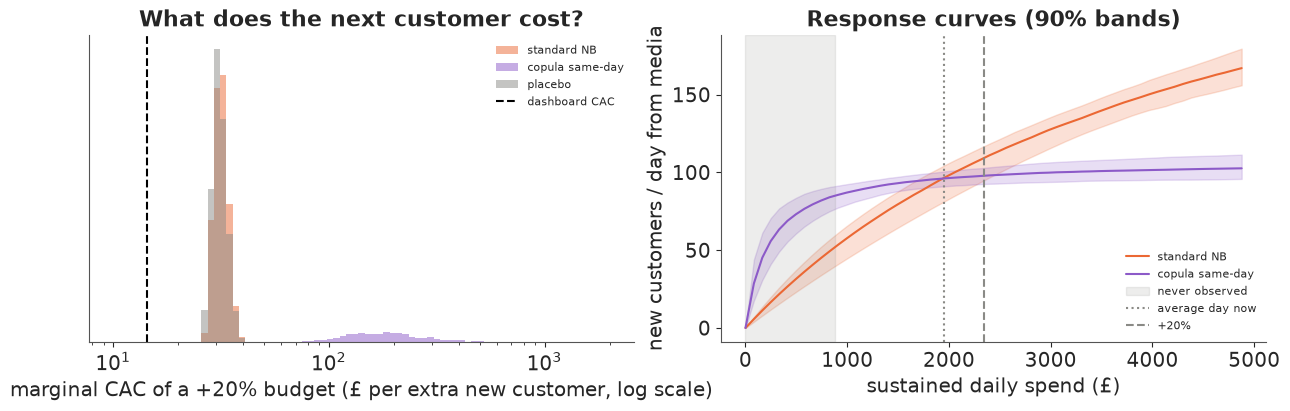

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.geomspace(10, 2000, 80)
for ans, c, lab in [(ans_naive, ORANGE, "standard NB"), (ans_pg, PURPLE, "copula same-day"),
                    (ans_pl, GREY, "placebo")]:
    axes[0].hist(np.clip(ans["marginal CAC (+20%)"], 10, 2000), bins=bins, color=c, alpha=0.5,
                 label=lab, density=True)
axes[0].set_xscale("log")
axes[0].axvline(spend.sum() / y.sum(), color="k", ls="--", label="dashboard CAC")
axes[0].set_xlabel("marginal CAC of a +20% budget (£ per extra new customer, log scale)")
axes[0].set_yticks([])
axes[0].legend(fontsize=8)
axes[0].set_title("What does the next customer cost?")

mults = np.linspace(0.0, 2.5, 60)
for idt, pre, c, lab in [(idata_naive, "", ORANGE, "standard NB"), (idata_pg, "pg::", PURPLE, "copula same-day")]:
    a, kh, be = media_draws(idt, x, pre, n_draws=500)
    a_bar = a.mean(axis=1, keepdims=True)
    curves = be * mults * a_bar / (mults * a_bar + kh)
    lo, med, hi = np.quantile(curves, [0.05, 0.5, 0.95], axis=0)
    axes[1].fill_between(mults * X_SCALE, lo, hi, color=c, alpha=0.2)
    axes[1].plot(mults * X_SCALE, med, color=c, lw=1.5, label=lab)
axes[1].axvspan(0, np.quantile(spend, 0.01), color=GREY, alpha=0.15, label="never observed")
axes[1].axvline(X_SCALE, color=GREY, ls=":", label="average day now")
axes[1].axvline(1.2 * X_SCALE, color=GREY, ls="--", label="+20%")
axes[1].set_xlabel("sustained daily spend (£)")
axes[1].set_ylabel("new customers / day from media")
axes[1].legend(fontsize=8)
axes[1].set_title("Response curves (90% bands)");

The results for a web page (for a non-technical audience) are exported as a small JSON file.

In [25]:
import json
from pathlib import Path

curve_q = {}
for idt, pre, key in [(idata_naive, "", "standard"), (idata_pg, "pg::", "corrected")]:
    a, kh, be = media_draws(idt, x, pre, n_draws=500)
    a_bar = a.mean(axis=1, keepdims=True)
    curves = be * mults * a_bar / (mults * a_bar + kh)
    curve_q[key] = {q: np.quantile(curves, float(q), axis=0).round(1).tolist()
                    for q in ("0.05", "0.25", "0.5", "0.75", "0.95")}
sub = np.random.default_rng(0).choice(len(ans_pg["marginal CAC (+20%)"]), 300, replace=False)
export = {
    "id": "E32", "title": "Does more spend buy more customers - or does demand buy more spend?",
    "brand": "UK skincare brand (anonymised, Conjura open data)", "currency": "GBP",
    "period": f"{dates.min().date()} to {dates.max().date()}",
    "dashboard_cac": round(float(spend.sum() / y.sum()), 2),
    "marginal_cac_draws": {k: np.round(v["marginal CAC (+20%)"][sub], 1).tolist()
                           for k, v in [("standard", ans_naive), ("corrected", ans_pg), ("placebo", ans_pl)]},
    "marginal_cac_summary": {k: {q: round(float(np.quantile(v["marginal CAC (+20%)"], q)), 1)
                                 for q in (0.05, 0.5, 0.95)}
                             for k, v in [("standard", ans_naive), ("corrected", ans_pg), ("placebo", ans_pl)]},
    "rho": {"median": round(float(np.median(idata_pg.posterior["pg::rho"])), 2),
            "q05": round(float(np.quantile(idata_pg.posterior["pg::rho"], 0.05)), 2),
            "q95": round(float(np.quantile(idata_pg.posterior["pg::rho"], 0.95)), 2)},
    "curves": {"spend_gbp_per_day": np.round(mults * X_SCALE, 0).tolist(), "quantiles": curve_q,
               "spend_today": round(float(X_SCALE), 0), "lowest_observed": round(float(spend.min()), 0)},
}
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
out = root / ".scratch" / "artifact" / "E32.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, separators=(",", ":")))
print(f"wrote {out.name}: {out.stat().st_size / 1024:.0f} KB")

wrote E32.json: 9 KB


The answer to finance, in the order they should hear it:

1. **The dashboard CAC of £14 is not an answer to the question.** It divides all spend by
   all new customers, including the ones who would have come anyway.
2. **The standard MMM says the next customer costs about £32** (90%: £28-36). That number
   assumes spend never reacted to demand. The placebo gives the same £31, as it should.
3. **Allowing spend to chase demand changes the answer by a factor of six**: about £200 per
   extra customer, with a 90% interval of roughly £100-430 (it moves by ±£20 between
   builds). The response curve is nearly flat
   over every level of spend the brand has used (the grey band shows spend levels never
   observed; the lowest day was £760). The day-to-day link between spend and new customers
   is mostly demand moving both, not media moving customers.
4. **What rests on what.** Point 3 rests on the Gaussian-copula assumption, which these data
   cannot test. The placebo, LOO and the fake-data study support it without proving it, and
   the interval in point 3 is too narrow (see the PPC). Neither model can say what switching
   media *off* would do, because spend never went near zero. That is why the "media share"
   and "average CAC" rows barely change between models: below the observed range they are
   set by the curve's functional form, not by data.

**Recommendation:** do not fund the +20% on the strength of the dashboard or the standard
MMM. The two models disagree by a factor of six, and a geo holdout test settles it: raise
spend by 20% in randomly chosen regions for 4-6 weeks. At £32 per customer the extra
customers would be easy to see; at £200 there would be almost none. The test is cheap
compared with a year of +20% budget.


## What to take away about writing likelihoods

- **Start from the story, not from the menu of distributions.** The fix here was not a
  different family; it was noticing that one assumption (spend independent of demand) was
  false and writing a joint story that did not make it.
- **Keep what is right.** The negative-binomial *margin* survived untouched as the causal
  (interventional) distribution; the copula only changed how it is conditioned. That also
  kept the parameters interpretable and the decision quantity unchanged.
- **Discrete outcomes turn densities into interval probabilities**, and interval
  probabilities need log-space arithmetic and tail switching to survive a sampler.
- **Test the likelihood before the model**: reduction to a known case, normalisation,
  agreement with a simulator of the same story, gradients, tails. Five cheap tests caught
  every bug made while writing this notebook.
- **A likelihood that passes its unit tests can still answer the wrong question.** Only the
  fake-data study showed that the textbook correction breaks under persistent shocks; the
  derivation was general enough to fix it by changing one argument.
- **Name the untestable assumption, then attack it with what you can test** (a placebo, LOO,
  PPCs), and say plainly to the stakeholder which part of the answer rests on it.

## Try it yourself

1. **Two channels.** Split spend into Google and Meta, each with its own curve and its own
   normal score. The copula becomes trivariate: $u_t \mid (c^G_t, c^M_t)$ is normal with mean
   $r^\top R^{-1} c_t$ and variance $1 - r^\top R^{-1} r$, where $R$ is the correlation of the two
   controls. Is Performance Max (Google) more endogenous than Meta, as you would expect from
   an algorithm that bids on predicted conversions?
2. **Composite-likelihood honesty.** The copula likelihood treats days as independent given
   the control, but the demand shocks are autocorrelated, so the posterior is too narrow.
   Refit on every 7th day (weekly-spaced days are nearly independent) and compare the width
   of the marginal-CAC interval. Or make the error AR(1) inside the copula - what changes in
   the likelihood?
3. **A different brand.** Pick another long series with `data.load("conjura_mmm")` (for
   example `36558b27715d6929312962cfe3a9488c`, a Home Improvement brand whose spend is much
   more skewed). Run the placebo first. Does the correction move the answer as much, and is
   the non-normality the method relies on stronger or weaker there?